# GROUP 2
**SCT213-C002-0029/2023 MARIA WANGARI KANENE**

**SCT213-C002-0053/2023 VINCENT KIMUTAI RONO**

# Banknote Authentication – Exploratory Data Analysis (EDA)
**ML II Unsupervised Learning Capstone – Step 1**

Dataset: UCI Banknote Authentication  
Features extracted from wavelet-transformed images of genuine and forged banknotes.

>  **Note for Step 2 (Preprocessing & Clustering):** The target column `class` has been **dropped** from `X` below. Only use `X` (scaled features) for clustering. `y` is kept separately for external metric evaluation (ARI, NMI).

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Consistent style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Dataset

In [3]:
# Load dataset 
col_names = ['variance', 'skewness', 'curtosis', 'entropy', 'class']

df = pd.read_csv(r'C:\Users\USER\Downloads\data_banknote_authentication.txt', header=None, names=col_names)

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1372, 5)


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## 3. Separate Features from Target

We separate `X` (features only) from `y` (ground truth class labels) **before any analysis**.  
This is critical for unsupervised learning — we **never feed the target into clustering**.

In [3]:
# ✅ Drop target column — X contains ONLY features
X = df.drop(columns=['class'])   # shape: (1372, 4)

# ✅ Keep y separately for external metric evaluation (ARI, NMI) in later steps
y = df['class']                  # 0 = genuine, 1 = forged

print(f'Feature matrix X: {X.shape}  →  columns: {list(X.columns)}')
print(f'Target vector  y: {y.shape}  →  classes: {y.unique()}')
print(f'Class distribution:\n{y.value_counts()}')

Feature matrix X: (1372, 4)  →  columns: ['variance', 'skewness', 'curtosis', 'entropy']
Target vector  y: (1372,)  →  classes: [0 1]
Class distribution:
class
0    762
1    610
Name: count, dtype: int64


## 4. Basic Summary Statistics

In [4]:
print('=== Summary Statistics (features only) ===')
X.describe().round(3)

=== Summary Statistics (features only) ===


,variance,skewness,curtosis,entropy
count,1372.000,1372.000,1372.000,1372.000
mean,0.434,1.922,1.398,-1.192
std,2.843,5.869,4.310,2.101
min,-7.042,-13.773,-5.286,-8.548
25%,-1.773,-1.708,-1.575,-2.413
50%,0.496,2.320,0.617,-0.587
75%,2.821,6.815,3.179,0.395
max,6.825,12.952,17.927,2.450


## 5. Missing Value Check

In [5]:
missing = X.isnull().sum()
print('Missing values per feature:')
print(missing)
print(f'\nTotal missing: {missing.sum()} — {"No imputation needed." if missing.sum() == 0 else "Imputation required!"}')

Missing values per feature:
variance    0
skewness    0
curtosis    0
entropy     0
dtype: int64

Total missing: 0 — No imputation needed.


## 6. Data Types & Duplicates

In [6]:
print('Data types:')
print(X.dtypes)

dupes = df.duplicated().sum()
print(f'\nDuplicate rows (full df): {dupes}')

Data types:
variance    float64
skewness    float64
curtosis    float64
entropy     float64
dtype: object

Duplicate rows (full df): 24


## 7. Feature Distributions (Histograms)

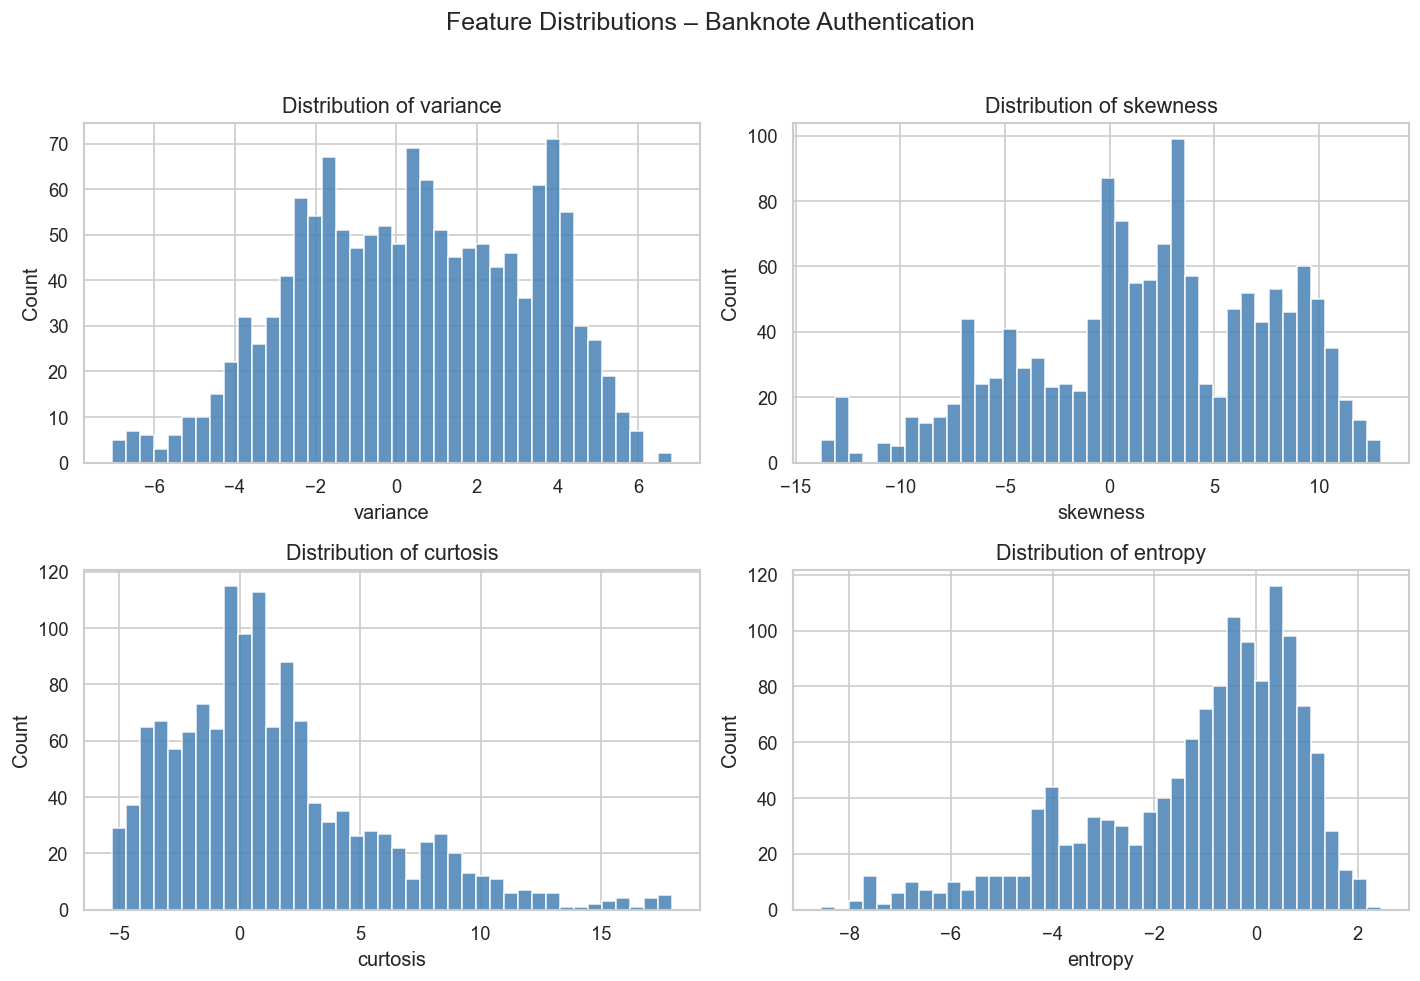

Figure 1 saved.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions – Banknote Authentication', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('fig1_feature_distributions.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## 8. Box Plots – Spread & Outliers

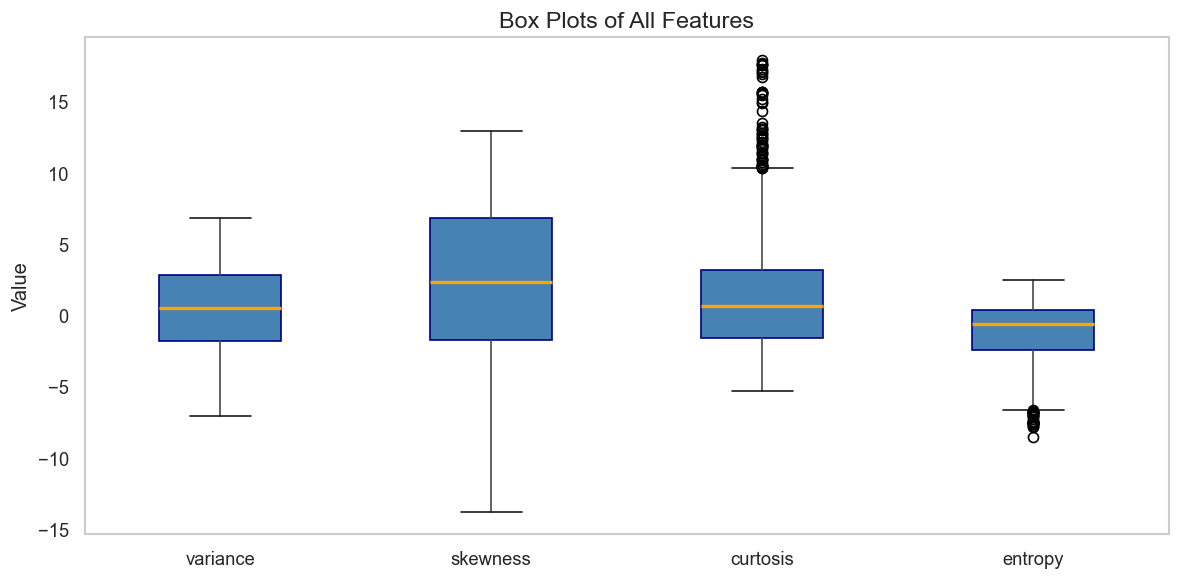

Figure 2 saved.


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
X.boxplot(ax=ax, grid=False, patch_artist=True,
          boxprops=dict(facecolor='steelblue', color='navy'),
          medianprops=dict(color='orange', linewidth=2))
ax.set_title('Box Plots of All Features', fontsize=14)
ax.set_ylabel('Value')
plt.tight_layout()
plt.savefig('fig2_boxplots.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## 9. Correlation Heatmap

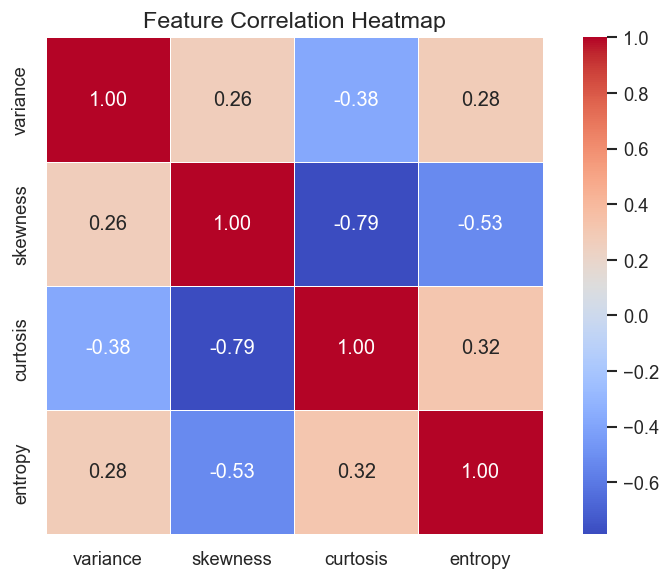

Figure 3 saved.


In [9]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## 10. Pair Plot (coloured by true class for insight — NOT used in clustering)

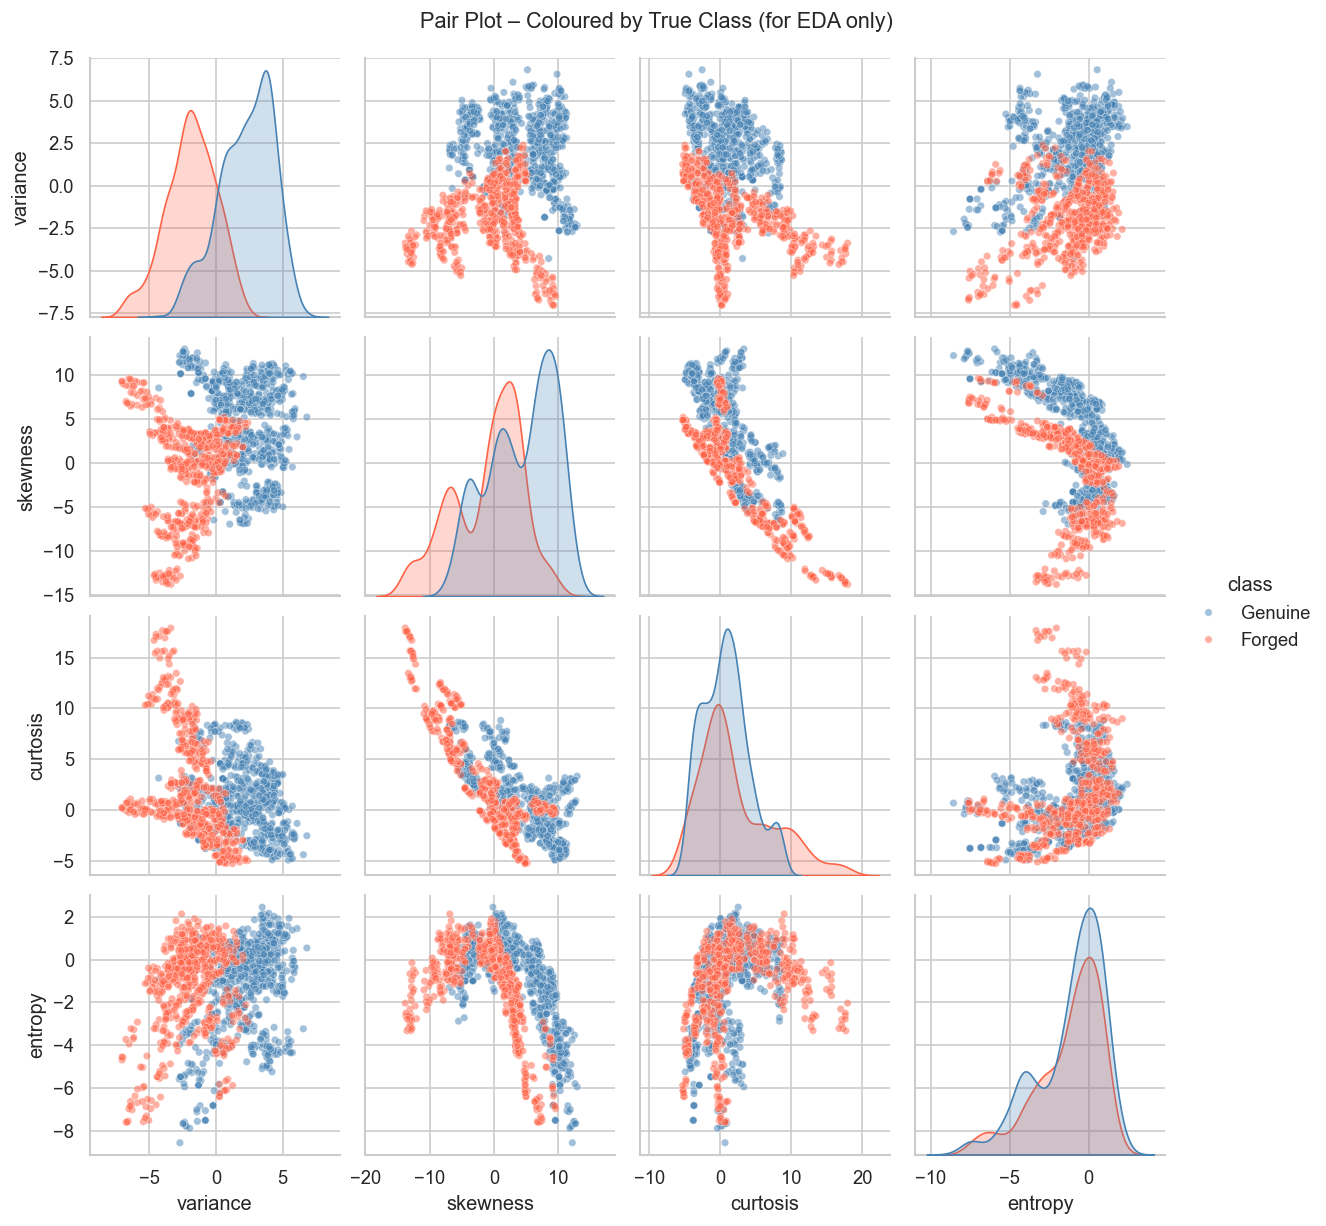

Figure 4 saved.


In [10]:
# We use y only for visual context — the clustering algorithms will NOT see it
df_vis = X.copy()
df_vis['class'] = y.map({0: 'Genuine', 1: 'Forged'})

pair_grid = sns.pairplot(df_vis, hue='class',
                         palette={'Genuine': 'steelblue', 'Forged': 'tomato'},
                         plot_kws={'alpha': 0.5, 's': 20},
                         diag_kind='kde')
pair_grid.fig.suptitle('Pair Plot – Coloured by True Class (for EDA only)', y=1.02, fontsize=13)
pair_grid.savefig('fig4_pairplot.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## 11. Skewness & Kurtosis Check

In [11]:
skew_kurt = pd.DataFrame({
    'Skewness': X.skew(),
    'Kurtosis': X.kurtosis()
}).round(3)

print('Skewness & Kurtosis:')
print(skew_kurt)

Skewness & Kurtosis:
          Skewness  Kurtosis
variance    -0.149    -0.752
skewness    -0.394    -0.437
curtosis     1.089     1.270
entropy     -1.022     0.497


## 12. Outlier Count (IQR Method)

In [12]:
def count_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))
    return outlier_mask.sum()

outlier_counts = count_outliers_iqr(X)
print('Outlier counts per feature (IQR method):')
print(outlier_counts)
print(f'\nTotal outliers: {outlier_counts.sum()} out of {len(X) * len(X.columns)} data points')

Outlier counts per feature (IQR method):
variance     0
skewness     0
curtosis    59
entropy     33
dtype: int64

Total outliers: 92 out of 5488 data points


## 13. EDA Summary & Justification for Unsupervised Clustering

| Property | Value |
|---|---|
| Instances | 1,372 |
| Features | 4 (all continuous, numeric) |
| Missing values | 0 |
| Ground truth classes | 2 (genuine, forged) |
| Class balance | ~55% genuine, ~45% forged |

**Why this dataset suits unsupervised clustering:**
- All 4 features are continuous and numeric — no encoding needed.
- No missing values — no imputation required.
- The features show meaningful variance and some inter-feature correlation, making PCA useful for dimensionality reduction.
- Ground truth labels exist, enabling external metric evaluation (ARI, NMI) after clustering.
- The dataset is compact (1,372 rows) — ideal for comparing K-means, hierarchical, and DBSCAN without heavy compute.

